# 探索性数据分析（EDA）

数据概览 · 目标变量分布 · 缺失值分析 · 时间分布

In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from logistics_delay.utils.paths import FIGURES_EDA, ensure_output_dirs
from logistics_delay.data.loader import load_raw_data_with_target

warnings.filterwarnings('ignore')

# ── Publication style ──────────────────────────
PALETTE = {
    "blue_main": "#0F4D92", "blue_secondary": "#3775BA",
    "green_1": "#DDF3DE", "green_2": "#AADCA9", "green_3": "#8BCF8B",
    "red_1": "#F6CFCB", "red_2": "#E9A6A1", "red_strong": "#B64342",
    "neutral": "#CFCECE", "highlight": "#FFD700",
    "teal": "#42949E", "violet": "#9A4D8E",
}

plt.rcParams.update({
    "font.family": ["Arial", "Microsoft YaHei", "Helvetica", "DejaVu Sans", "sans-serif"],
    "font.size": 15,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.linewidth": 2.5,
    "legend.frameon": False,
    "svg.fonttype": "none",
})
sns.set_style('whitegrid')
plt.rcParams['axes.unicode_minus'] = False
ensure_output_dirs()
print("[OK] 导入完成")

[OK] 导入完成


In [2]:
# ── 加载数据 ──
df = load_raw_data_with_target()
print(f"列名：{list(df.columns)}")

[loader] 原始数据加载完成: (6880, 32)
[loader] 目标变量构建完成: 延误=4332, 准时=2548
[loader] 延误率: 62.97%
列名：['GpsProvider', 'BookingID', 'Market/Regular', 'BookingID_Date', 'vehicle_no', 'Origin_Location', 'Destination_Location', 'Org_lat_lon', 'Des_lat_lon', 'Data_Ping_time', 'Planned_ETA', 'Current_Location', 'DestinationLocation', 'actual_eta', 'Curr_lat', 'Curr_lon', 'ontime', 'delay', 'OriginLocation_Code', 'DestinationLocation_Code', 'trip_start_date', 'trip_end_date', 'TRANSPORTATION_DISTANCE_IN_KM', 'vehicleType', 'Minimum_kms_to_be_covered_in_a_day', 'Driver_Name', 'Driver_MobileNo', 'customerID', 'customerNameCode', 'supplierID', 'supplierNameCode', 'Material Shipped', 'Answer']


延误（1）：4332 条
准时（0）：2548 条
延误率：62.97%


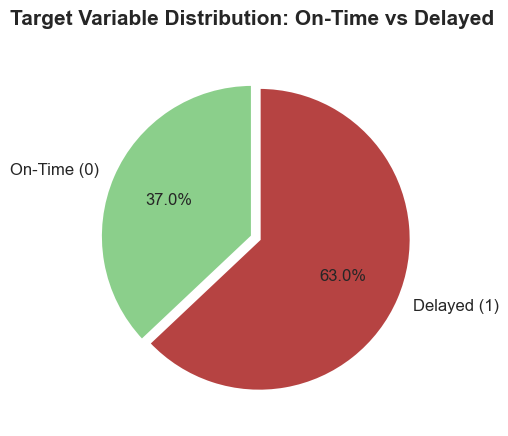

图片已保存到： C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\figures\eda\target_distribution.png


In [3]:
# ── 目标变量分析 ──
counts = df['Answer'].value_counts()
print(f"延误（1）：{counts.get(1)} 条")
print(f"准时（0）：{counts.get(0)} 条")
print(f"延误率：{counts.get(1)/len(df)*100:.2f}%")

fig, ax = plt.subplots(figsize=(6, 5))
colors = [PALETTE['green_3'], PALETTE['red_strong']]
wedges, texts, autotexts = ax.pie(
    [counts.get(0), counts.get(1)], labels=['On-Time (0)', 'Delayed (1)'],
    autopct='%1.1f%%', startangle=90, colors=colors, explode=(0, 0.05),
    textprops={'fontsize': 12}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Target Variable Distribution: On-Time vs Delayed', fontsize=15, fontweight='bold', pad=16)
fig.tight_layout(pad=2)
fig.savefig(FIGURES_EDA / 'target_distribution.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_EDA / 'target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("图片已保存到：", FIGURES_EDA / 'target_distribution.png')

In [4]:
# ── 缺失值分析 ──
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'缺失数量': missing, '缺失比例 (%)': missing_pct})
missing_df = missing_df[missing_df['缺失数量'] > 0].sort_values('缺失数量', ascending=False)
print(f"存在缺失值的字段：{len(missing_df)} 个")
print(missing_df.to_string())

存在缺失值的字段：16 个
                                    缺失数量  缺失比例 (%)
ontime                              4332     62.97
Driver_MobileNo                     4189     60.89
Minimum_kms_to_be_covered_in_a_day  4060     59.01
Driver_Name                         3429     49.84
delay                               2538     36.89
Current_Location                     964     14.01
Curr_lon                             953     13.85
GpsProvider                          953     13.85
Data_Ping_time                       953     13.85
Curr_lat                             953     13.85
vehicleType                          828     12.03
TRANSPORTATION_DISTANCE_IN_KM        712     10.35
trip_end_date                        194      2.82
actual_eta                            37      0.54
DestinationLocation_Code              27      0.39
OriginLocation_Code                    3      0.04


In [5]:
# ── 时间范围分析 ──
df['trip_start_date'] = pd.to_datetime(df['trip_start_date'], errors='coerce')
print(f"日期范围：{df['trip_start_date'].min().date()} ~ {df['trip_start_date'].max().date()}")
df['year'] = df['trip_start_date'].dt.year
for yr, cnt in df['year'].value_counts().sort_index().items():
    print(f"  {int(yr)}年：{cnt} 条")

日期范围：1899-12-30 ~ 2020-12-03
  1899年：2 条
  2019年：3283 条
  2020年：3595 条


均值：553.9 km | 中位数：160.0 km | 缺失：712 条
图片已保存到： C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\figures\eda\distance_distribution.png


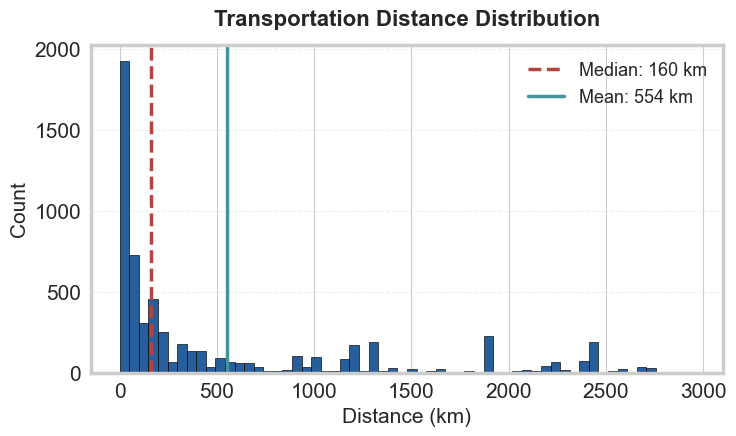

In [6]:
# ── 运输距离分析 ──
dist = df['TRANSPORTATION_DISTANCE_IN_KM'].dropna()
print(f"均值：{dist.mean():.1f} km | 中位数：{dist.median():.1f} km | 缺失：{df['TRANSPORTATION_DISTANCE_IN_KM'].isna().sum()} 条")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(dist, bins=60, color=PALETTE['blue_main'], edgecolor='black', alpha=0.9, linewidth=0.5)
ax.axvline(dist.median(), color=PALETTE['red_strong'], linestyle='--', linewidth=2.5,
           label=f'Median: {dist.median():.0f} km')
ax.axvline(dist.mean(), color=PALETTE['teal'], linestyle='-', linewidth=2.5,
           label=f'Mean: {dist.mean():.0f} km')
ax.set_xlabel('Distance (km)', fontsize=15)
ax.set_ylabel('Count', fontsize=15)
ax.set_title('Transportation Distance Distribution', fontsize=16, fontweight='bold', pad=14)
ax.legend(fontsize=13)
ax.grid(axis='y', linestyle='--', alpha=0.3)
fig.tight_layout(pad=2)
fig.savefig(FIGURES_EDA / 'distance_distribution.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_EDA / 'distance_distribution.png', dpi=300, bbox_inches='tight')
print("图片已保存到：", FIGURES_EDA / 'distance_distribution.png')

In [ ]:
# ── 计划天数分布（与运输距离相同的方式）──
df['planned_eta_time'] = pd.to_datetime(df['Planned_ETA'], errors='coerce')
df['BookingID_Date'] = pd.to_datetime(df['BookingID_Date'], unit='D', origin='1899-12-30')
df['planned_days'] = (df['planned_eta_time'].dt.normalize() - df['BookingID_Date'].dt.normalize()).dt.days

df.loc[df['planned_days'] < 0, 'planned_days'] = None
df.loc[df['planned_days'] > 180, 'planned_days'] = None
pd_days = df['planned_days'].dropna()
print(f"均值：{pd_days.mean():.1f} 天 | 中位数：{pd_days.median():.0f} 天 | 缺失：{df['planned_days'].isna().sum()} 条")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(pd_days, bins=60, color=PALETTE['blue_main'], edgecolor='black', alpha=0.9, linewidth=0.5)
ax.axvline(pd_days.median(), color=PALETTE['red_strong'], linestyle='--', linewidth=2.5,
           label=f'Median: {pd_days.median():.0f} days')
ax.axvline(pd_days.mean(), color=PALETTE['teal'], linestyle='-', linewidth=2.5,
           label=f'Mean: {pd_days.mean():.1f} days')
ax.set_xlabel('Planned Days (days)', fontsize=15)
ax.set_ylabel('Count', fontsize=15)
ax.set_title('Planned Days Distribution', fontsize=16, fontweight='bold', pad=14)
ax.legend(fontsize=13)
ax.grid(axis='y', linestyle='--', alpha=0.3)
fig.tight_layout(pad=2)
fig.savefig(FIGURES_EDA / 'planned_days_distribution.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_EDA / 'planned_days_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("图片已保存到：", FIGURES_EDA / 'planned_days_distribution.png')

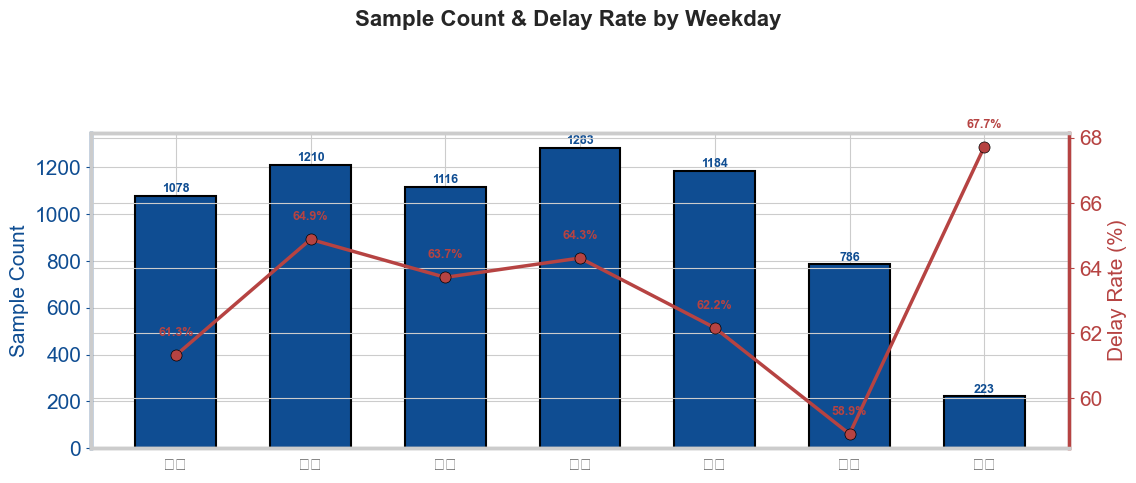

图片已保存到： C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\figures\eda\weekday_distribution.png


In [7]:
# ── 星期分布 ──
df['weekday'] = df['trip_start_date'].dt.dayofweek
wd_stats = df.groupby('weekday')['Answer'].agg(['count', 'mean'])
wd_stats['mean'] = wd_stats['mean'] * 100
weekday_names = ['周一', '周二', '周三', '周四', '周五', '周六', '周日']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(7), wd_stats['count'], color=PALETTE['blue_main'],
              edgecolor='black', linewidth=1.5, width=0.6)
for bar, val in zip(bars, wd_stats['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{int(val)}', ha='center', va='bottom', fontsize=9, fontweight='bold',
            color=PALETTE['blue_main'])
ax.set_xticks(range(7))
ax.set_xticklabels(weekday_names, fontsize=12)
ax.set_ylabel('Sample Count', fontsize=15, color=PALETTE['blue_main'])
ax.spines['left'].set_color(PALETTE['blue_main'])
ax.tick_params(axis='y', colors=PALETTE['blue_main'])

ax2 = ax.twinx()
ax2.plot(range(7), wd_stats['mean'], 'o-', color=PALETTE['red_strong'],
         linewidth=2.5, markersize=8, markeredgecolor='black', markeredgewidth=0.5)
for i, v in enumerate(wd_stats['mean']):
    ax2.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9,
             fontweight='bold', color=PALETTE['red_strong'])
ax2.set_ylabel('Delay Rate (%)', fontsize=15, color=PALETTE['red_strong'])
ax2.spines['right'].set_color(PALETTE['red_strong'])
ax2.tick_params(axis='y', colors=PALETTE['red_strong'])

fig.suptitle('Sample Count & Delay Rate by Weekday', fontsize=16, fontweight='bold', y=1.01)
fig.tight_layout(pad=2)
fig.savefig(FIGURES_EDA / 'weekday_distribution.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_EDA / 'weekday_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("图片已保存到：", FIGURES_EDA / 'weekday_distribution.png')

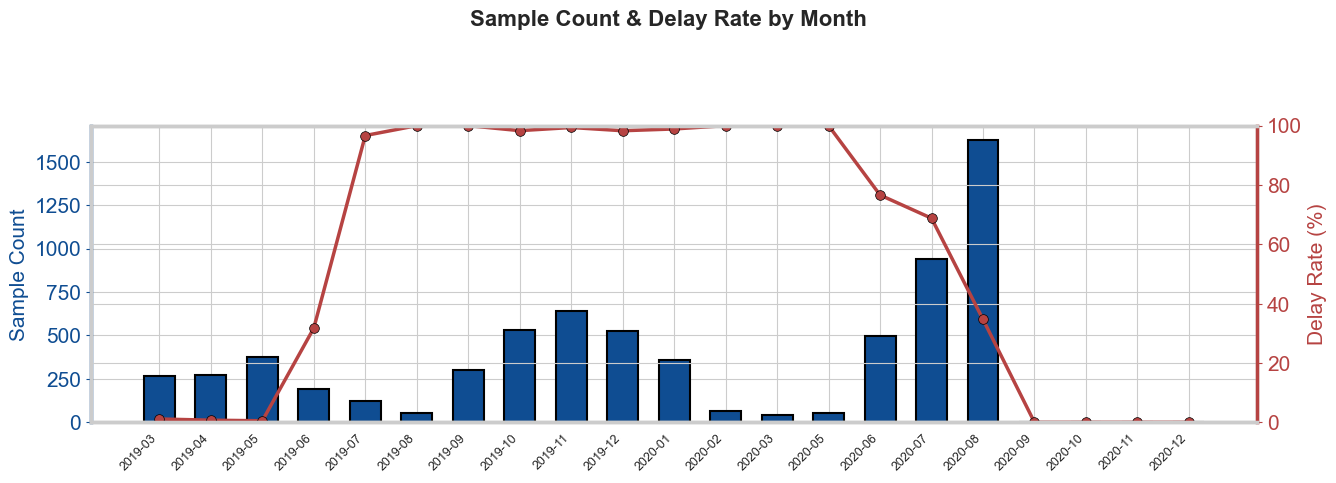

图片已保存到： C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\figures\eda\monthly_distribution.png


In [8]:
# ── 月份分布 ──
df_month = df[df['trip_start_date'].dt.year >= 2019].copy()
df_month['year_month'] = df_month['trip_start_date'].dt.to_period('M').astype(str)
monthly_stats = df_month.groupby('year_month')['Answer'].agg(['count', 'mean'])
monthly_stats['mean'] = monthly_stats['mean'] * 100

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(monthly_stats))
bars = ax.bar(x, monthly_stats['count'], color=PALETTE['blue_main'],
              edgecolor='black', linewidth=1.5, width=0.6)
ax.set_xticks(range(len(monthly_stats)))
ax.set_xticklabels(monthly_stats.index, fontsize=9, rotation=45, ha='right')
ax.set_ylabel('Sample Count', fontsize=15, color=PALETTE['blue_main'])
ax.spines['left'].set_color(PALETTE['blue_main'])
ax.tick_params(axis='y', colors=PALETTE['blue_main'])

ax2 = ax.twinx()
ax2.plot(x, monthly_stats['mean'], 'o-', color=PALETTE['red_strong'],
         linewidth=2.5, markersize=7, markeredgecolor='black', markeredgewidth=0.5)
ax2.set_ylabel('Delay Rate (%)', fontsize=15, color=PALETTE['red_strong'])
ax2.spines['right'].set_color(PALETTE['red_strong'])
ax2.tick_params(axis='y', colors=PALETTE['red_strong'])
ax2.set_ylim(0, 100)

fig.suptitle('Sample Count & Delay Rate by Month', fontsize=16, fontweight='bold', y=1.01)
fig.tight_layout(pad=2)
fig.savefig(FIGURES_EDA / 'monthly_distribution.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_EDA / 'monthly_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("图片已保存到：", FIGURES_EDA / 'monthly_distribution.png')

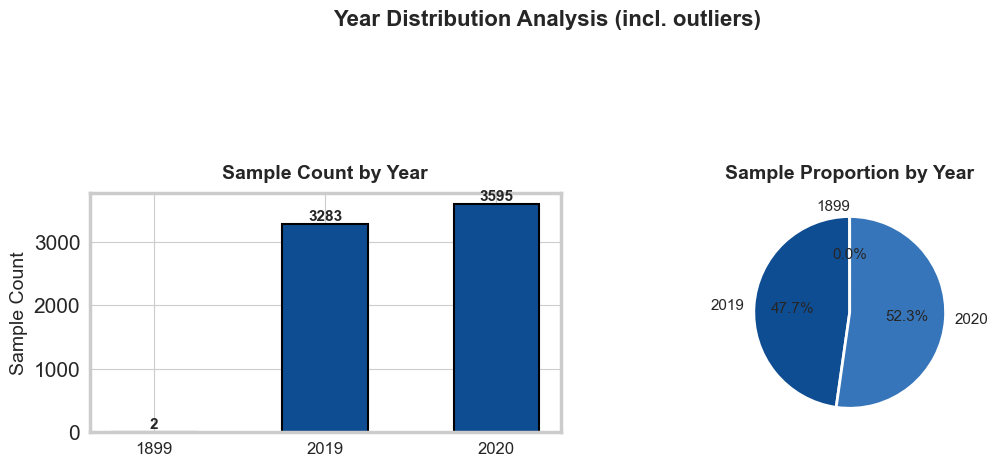

图片已保存到： C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\figures\eda\year_distribution.png


In [9]:
# ── 年份分布（包含异常值）──
year_counts = df['year'].value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 左：条形图
colors_bar = [PALETTE['neutral'] if y < 2019 else PALETTE['blue_main'] for y in year_counts.index]
bars = ax1.bar(range(len(year_counts)), year_counts.values, color=colors_bar,
               edgecolor='black', linewidth=1.5, width=0.5)
for bar, val in zip(bars, year_counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
             f'{int(val)}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_xticks(range(len(year_counts)))
ax1.set_xticklabels([f'{int(y)}' for y in year_counts.index], fontsize=12)
ax1.set_ylabel('Sample Count', fontsize=14)
ax1.set_title('Sample Count by Year', fontsize=14, fontweight='bold', pad=10)

# 右：饼图
colors_pie = [PALETTE['neutral'], PALETTE['blue_main'], PALETTE['blue_secondary']]
wedges, texts, autotexts = ax2.pie(
    year_counts.values, labels=[f'{int(y)}' for y in year_counts.index],
    autopct='%1.1f%%', startangle=90, colors=colors_pie,
    textprops={'fontsize': 11}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Sample Proportion by Year', fontsize=14, fontweight='bold', pad=10)

fig.suptitle('Year Distribution Analysis (incl. outliers)', fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout(pad=3)
fig.savefig(FIGURES_EDA / 'year_distribution.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_EDA / 'year_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("图片已保存到：", FIGURES_EDA / 'year_distribution.png')

In [10]:
print(f"[OK] EDA 完成。总样本：{len(df)}，延误率：{df['Answer'].mean()*100:.2f}%")

[OK] EDA 完成。总样本：6880，延误率：62.97%
